In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv("hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df_numeric = df.select_dtypes(include = ['number'])
df_numeric.skew().sort_values(ascending = False)

babies                            24.646545
previous_cancellations            24.458049
previous_bookings_not_canceled    23.539800
adults                            18.317805
days_in_waiting_list              11.944353
adr                               10.530214
booking_changes                    6.000270
is_repeated_guest                  5.326315
required_car_parking_spaces        4.163233
children                           4.112590
stays_in_week_nights               2.862249
stays_in_weekend_nights            1.380046
total_of_special_requests          1.349189
lead_time                          1.346550
agent                              1.089386
company                            0.601600
is_canceled                        0.536678
arrival_date_day_of_month         -0.002000
arrival_date_week_number          -0.010014
arrival_date_year                 -0.232583
dtype: float64

In [7]:
df_numeric.kurt().sort_values(ascending = False)

babies                            1633.948235
adults                            1352.115116
adr                               1013.189851
previous_bookings_not_canceled     767.245210
previous_cancellations             674.073693
days_in_waiting_list               186.793070
booking_changes                     79.393605
required_car_parking_spaces         29.998056
is_repeated_guest                   26.370077
stays_in_week_nights                24.284555
children                            18.673692
stays_in_weekend_nights              7.174066
lead_time                            1.696449
total_of_special_requests            1.492565
agent                               -0.007180
company                             -0.490795
arrival_date_week_number            -0.986077
arrival_date_year                   -0.994564
arrival_date_day_of_month           -1.187168
is_canceled                         -1.712005
dtype: float64

In [65]:
right_skew = df_numeric.skew() > 1
right_skew_t = right_skew[right_skew]
right_skew_t.index

Index(['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
       'adults', 'children', 'babies', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'agent', 'days_in_waiting_list', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests'],
      dtype='object')

In [64]:
left_skew = df_numeric.skew() < -1
left_skew_t = left_skew[left_skew]
left_skew_t.index

Index([], dtype='object')

In [16]:
skew = df_numeric.skew()

near_normal = skew[(skew >= -1) & (skew <= 1)]

near_normal.index

Index(['is_canceled', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'company'],
      dtype='object')

In [20]:
df_numeric.skew().sort_values(ascending = False).head(1).index

Index(['babies'], dtype='object')

In [21]:
df_numeric.skew().sort_values(ascending = True).head(1).index

Index(['arrival_date_year'], dtype='object')

In [23]:
df_numeric.skew().sort_values(ascending = False).head(5)

babies                            24.646545
previous_cancellations            24.458049
previous_bookings_not_canceled    23.539800
adults                            18.317805
days_in_waiting_list              11.944353
dtype: float64

In [24]:
df_numeric.skew().sort_values(ascending = True).head(5)

arrival_date_year           -0.232583
arrival_date_week_number    -0.010014
arrival_date_day_of_month   -0.002000
is_canceled                  0.536678
company                      0.601600
dtype: float64

In [63]:
skew = df_numeric.skew()
near_nomal = skew[(skew >= -1) & (skew <= 1)]
print(near_normal)

is_canceled                  0.536678
arrival_date_year           -0.232583
arrival_date_week_number    -0.010014
arrival_date_day_of_month   -0.002000
company                      0.601600
dtype: float64


In [30]:
print(len(right_skew_t))
print(len(left_skew_t))
print(len(near_normal))

15
0
5


In [33]:
df_numeric.skew()[df_numeric.skew() > 1].sort_values(ascending = False).head(3)

babies                            24.646545
previous_cancellations            24.458049
previous_bookings_not_canceled    23.539800
dtype: float64

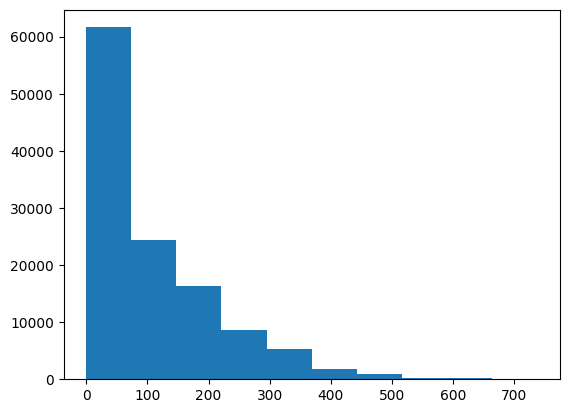

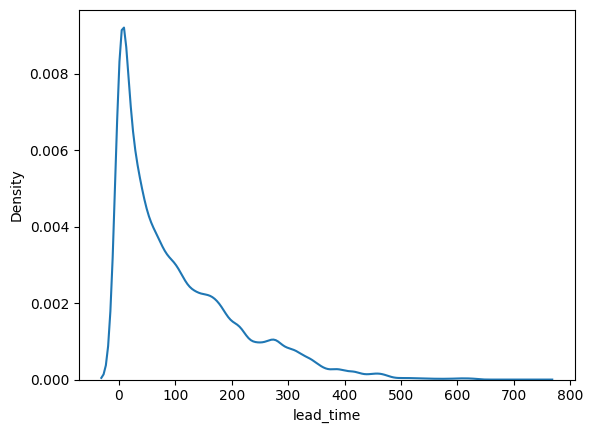

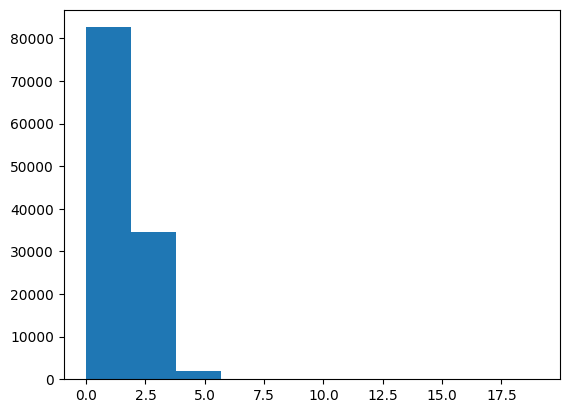

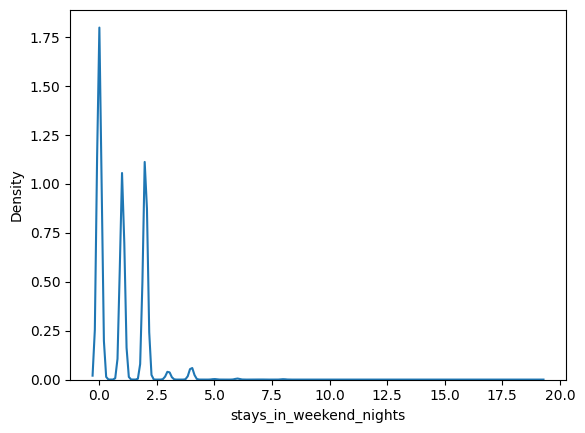

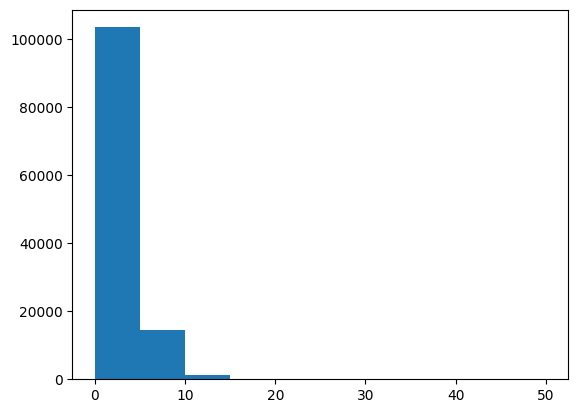

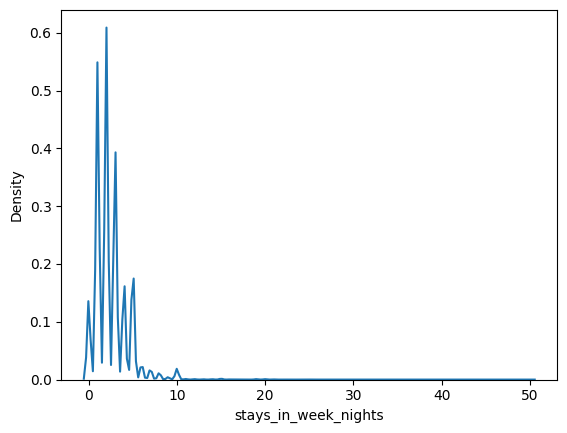

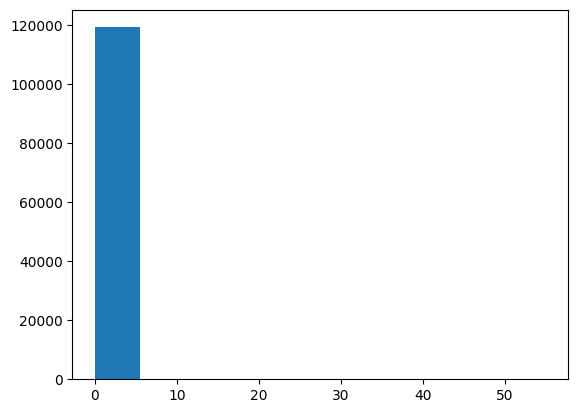

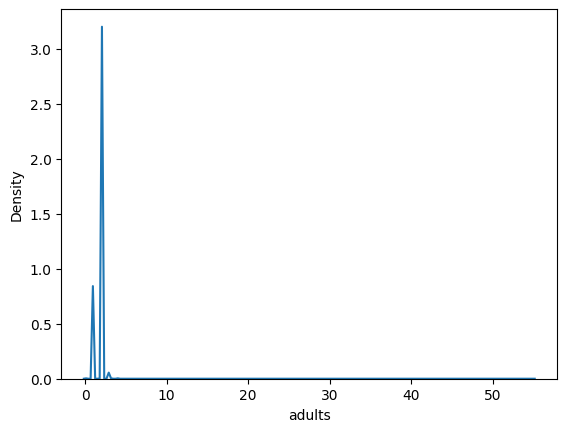

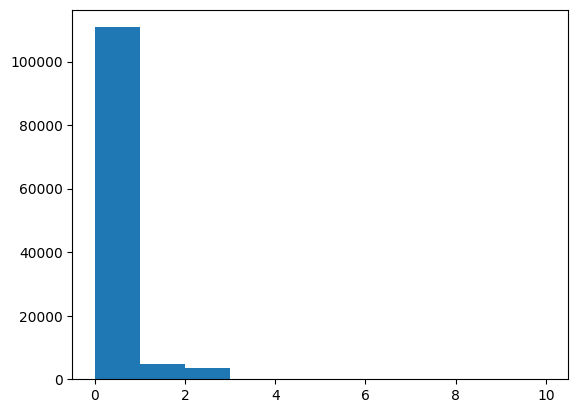

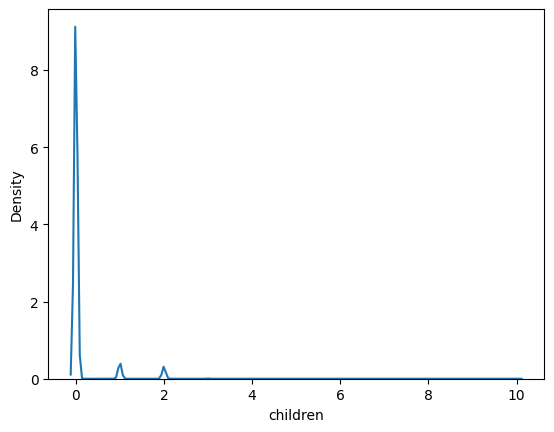

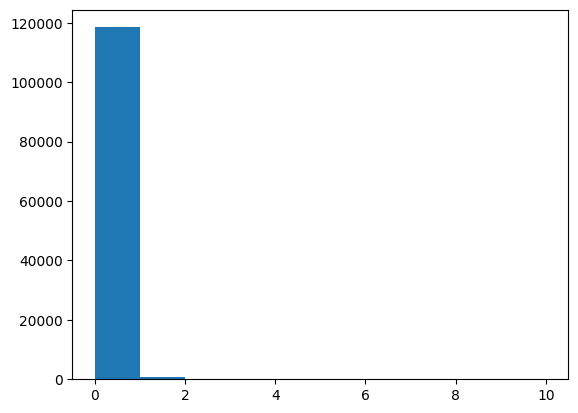

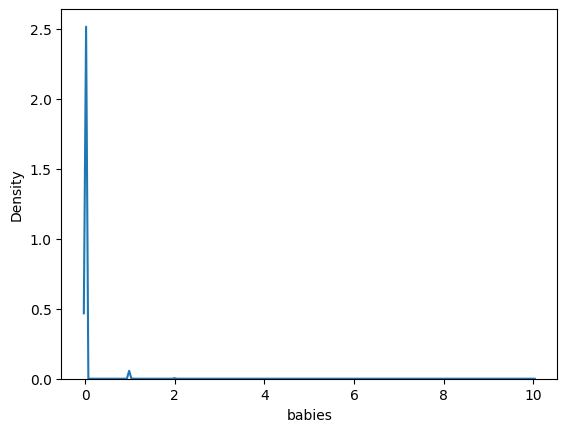

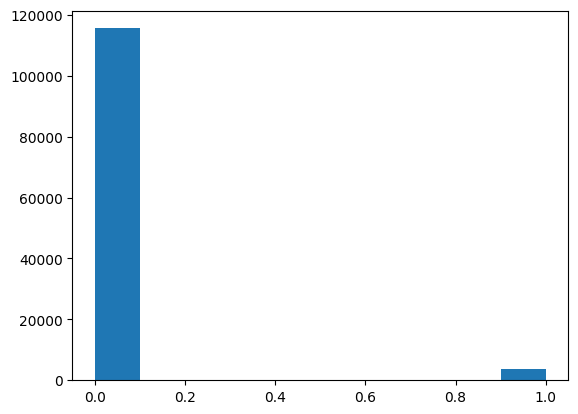

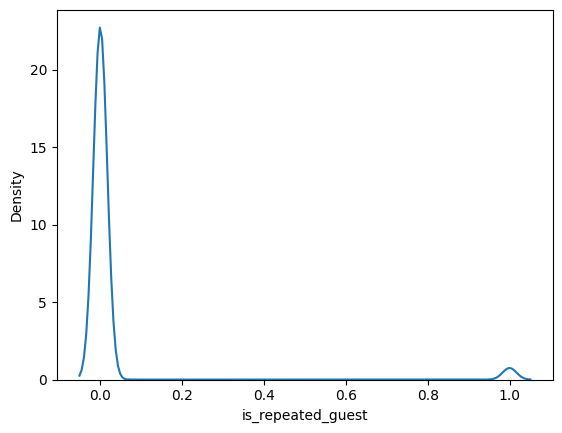

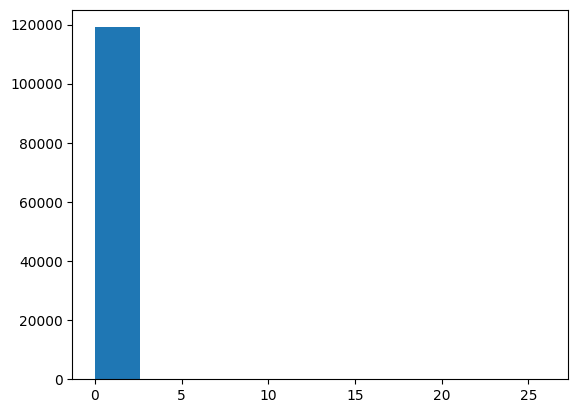

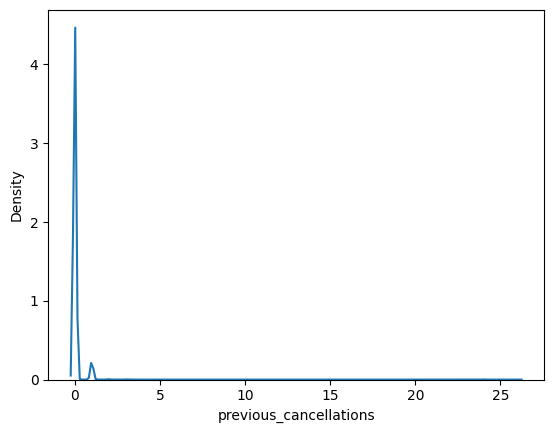

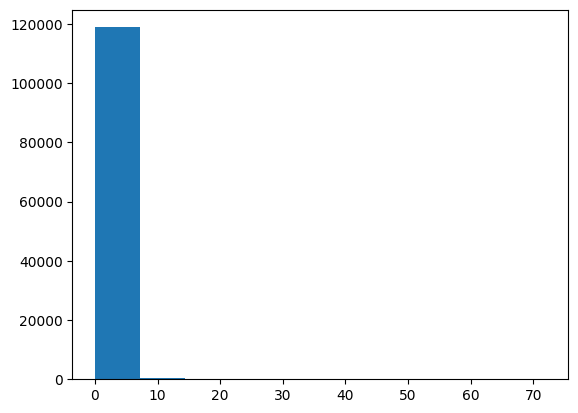

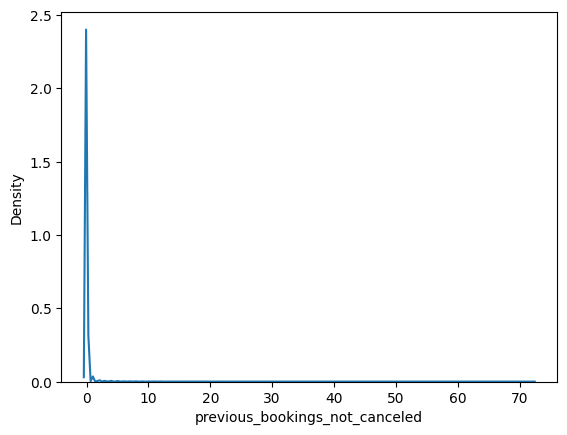

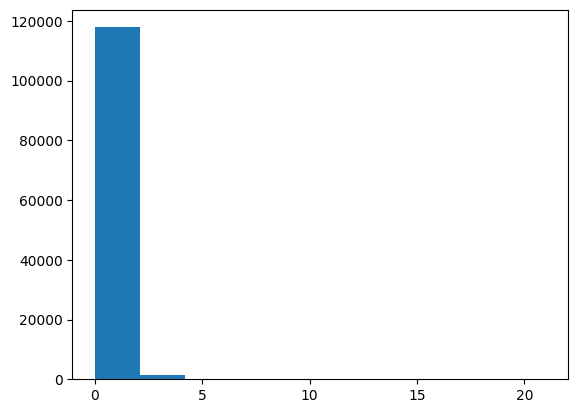

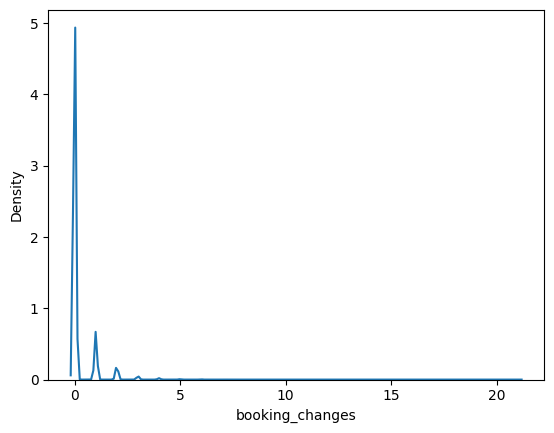

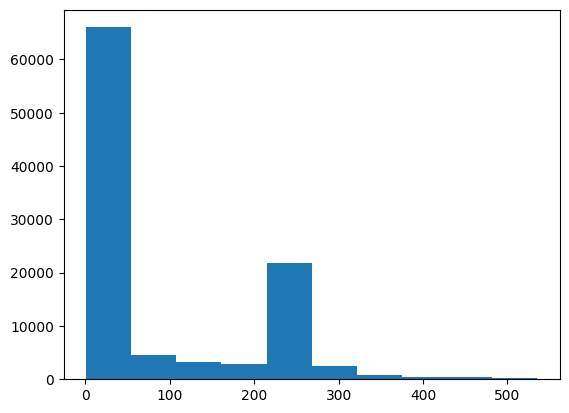

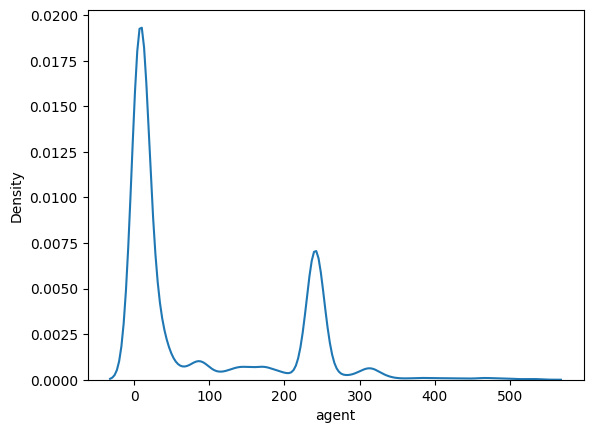

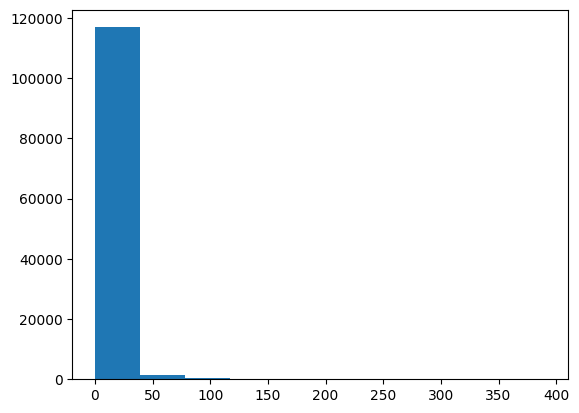

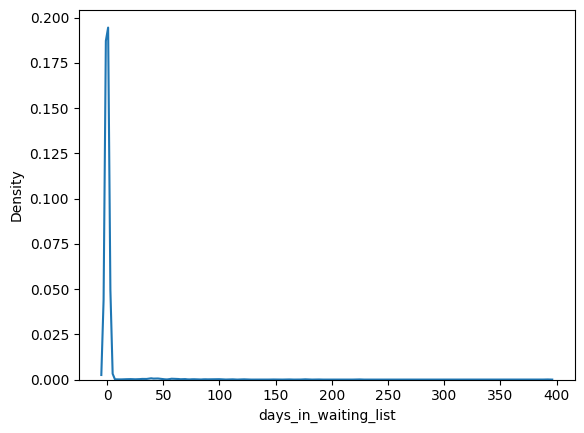

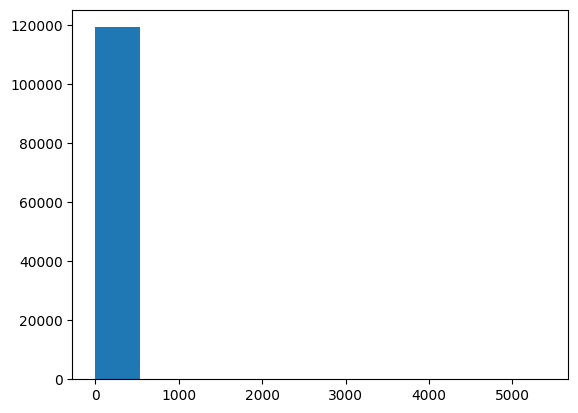

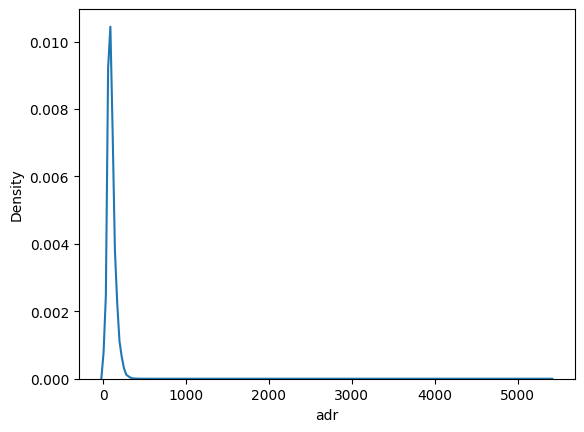

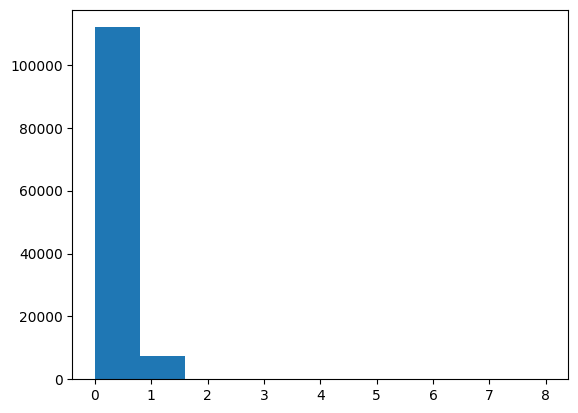

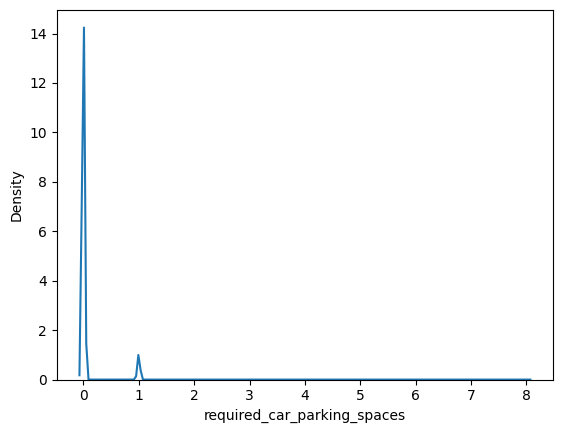

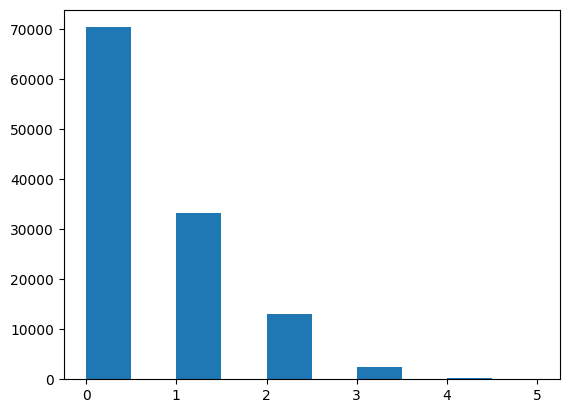

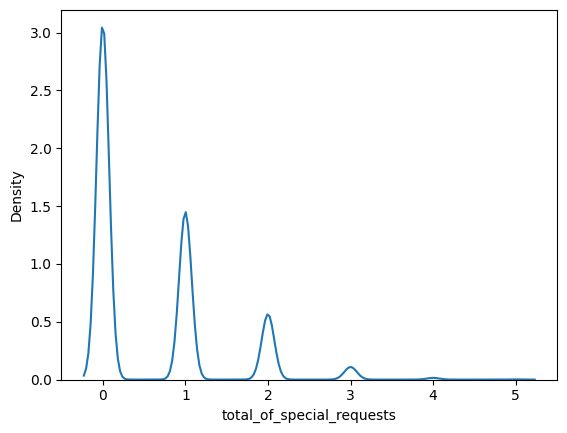

In [36]:
for i in df_numeric.skew()[df_numeric.skew() > 1].index : 
    plt.hist(df_numeric[i])
    plt.show()
    sns.kdeplot(df_numeric[i])
    plt.show()

In [46]:
skew = df_numeric.skew()
skew.abs().idxmin()

'arrival_date_day_of_month'

In [53]:
skew = df_numeric.skew()

skew.reindex(skew.abs().sort_values().head(5).index)

arrival_date_day_of_month   -0.002000
arrival_date_week_number    -0.010014
arrival_date_year           -0.232583
is_canceled                  0.536678
company                      0.601600
dtype: float64

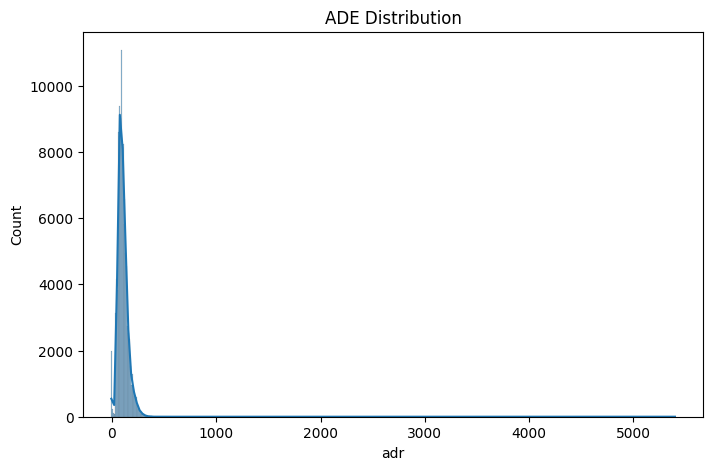

In [60]:
plt.figure(figsize=(8,5))
sns.histplot(df_numeric['adr'] , kde = True)
plt.title("ADE Distribution")
plt.show()


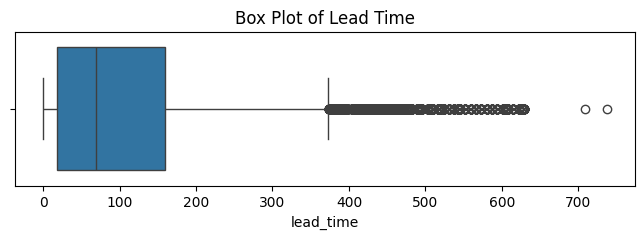

In [62]:
plt.figure(figsize=(8, 2))
sns.boxplot(x=df["lead_time"])
plt.title("Box Plot of Lead Time")
plt.show()